In [1]:
%load_ext autoreload
%autoreload 2

In [38]:
import numpy as np
import open3d as o3d
import matplotlib.pyplot as plt
%matplotlib inline

In [39]:
from octformer_inference import StandaloneOctformerInference
from salsanext_inference import SalsaNextInference
from plyfile import PlyData

In [4]:
data = PlyData.read('/data/scannet/scene0011_00_vh_clean_2.ply')

FileNotFoundError: [Errno 2] No such file or directory: '/data/scannet/scene0011_00_vh_clean_2.ply'

In [ ]:
vtx = data['vertex']
points = np.array([
    vtx['x'].tolist(),
    vtx['y'].tolist(),
    vtx['z'].tolist(),
    vtx['red'].tolist(),
    vtx['green'].tolist(),
    vtx['blue'].tolist()
]).T
points[:, 3:] = 255

In [5]:
config_path = '/home/docker_prism/octformer/configs/seg_scannet.yaml'
checkpoint_path = '/data/weights/octformer_scannet/best_model.pth'

In [7]:
colors = []
for i in range(2):
    for j in range(2):
        for k in range(2):
            colors.append([i, j, k])
colors[-1] = [0.5, 0.5, 0]
for i in range(2):
    for j in range(2):
        colors.append([i, j, 0.5])
        colors.append([i, 0.5, j])
        colors.append([0.5, i, j])
colors.append([0.5, 0.5, 0.5])
colors = np.array(colors).astype(np.float32)

In [6]:
class_labels = [
    'unknown',
    'wall',
    'floor',
    'cabinet',
    'bed',
    'chair',
    'sofa',
    'table',
    'door',
    'window',
    'bookshelf',
    'picture',
    'counter',
    'desk',
    'curtain',
    'refridgerator',
    'shower curtain',
    'toilet',
    'sink',
    'bathtub',
    'otherfurniture'
]

In [40]:
inference = SalsaNextInference()
#points_downsampled, colors_downsampled, predictions, probabilities = inference.predict(points)

Loading SalsaNext weights from /data/weights/pretrained/SalsaNext
SalsaNext model loaded successfully on cuda:0
Number of classes: 20


NameError: name 'predictions' is not defined

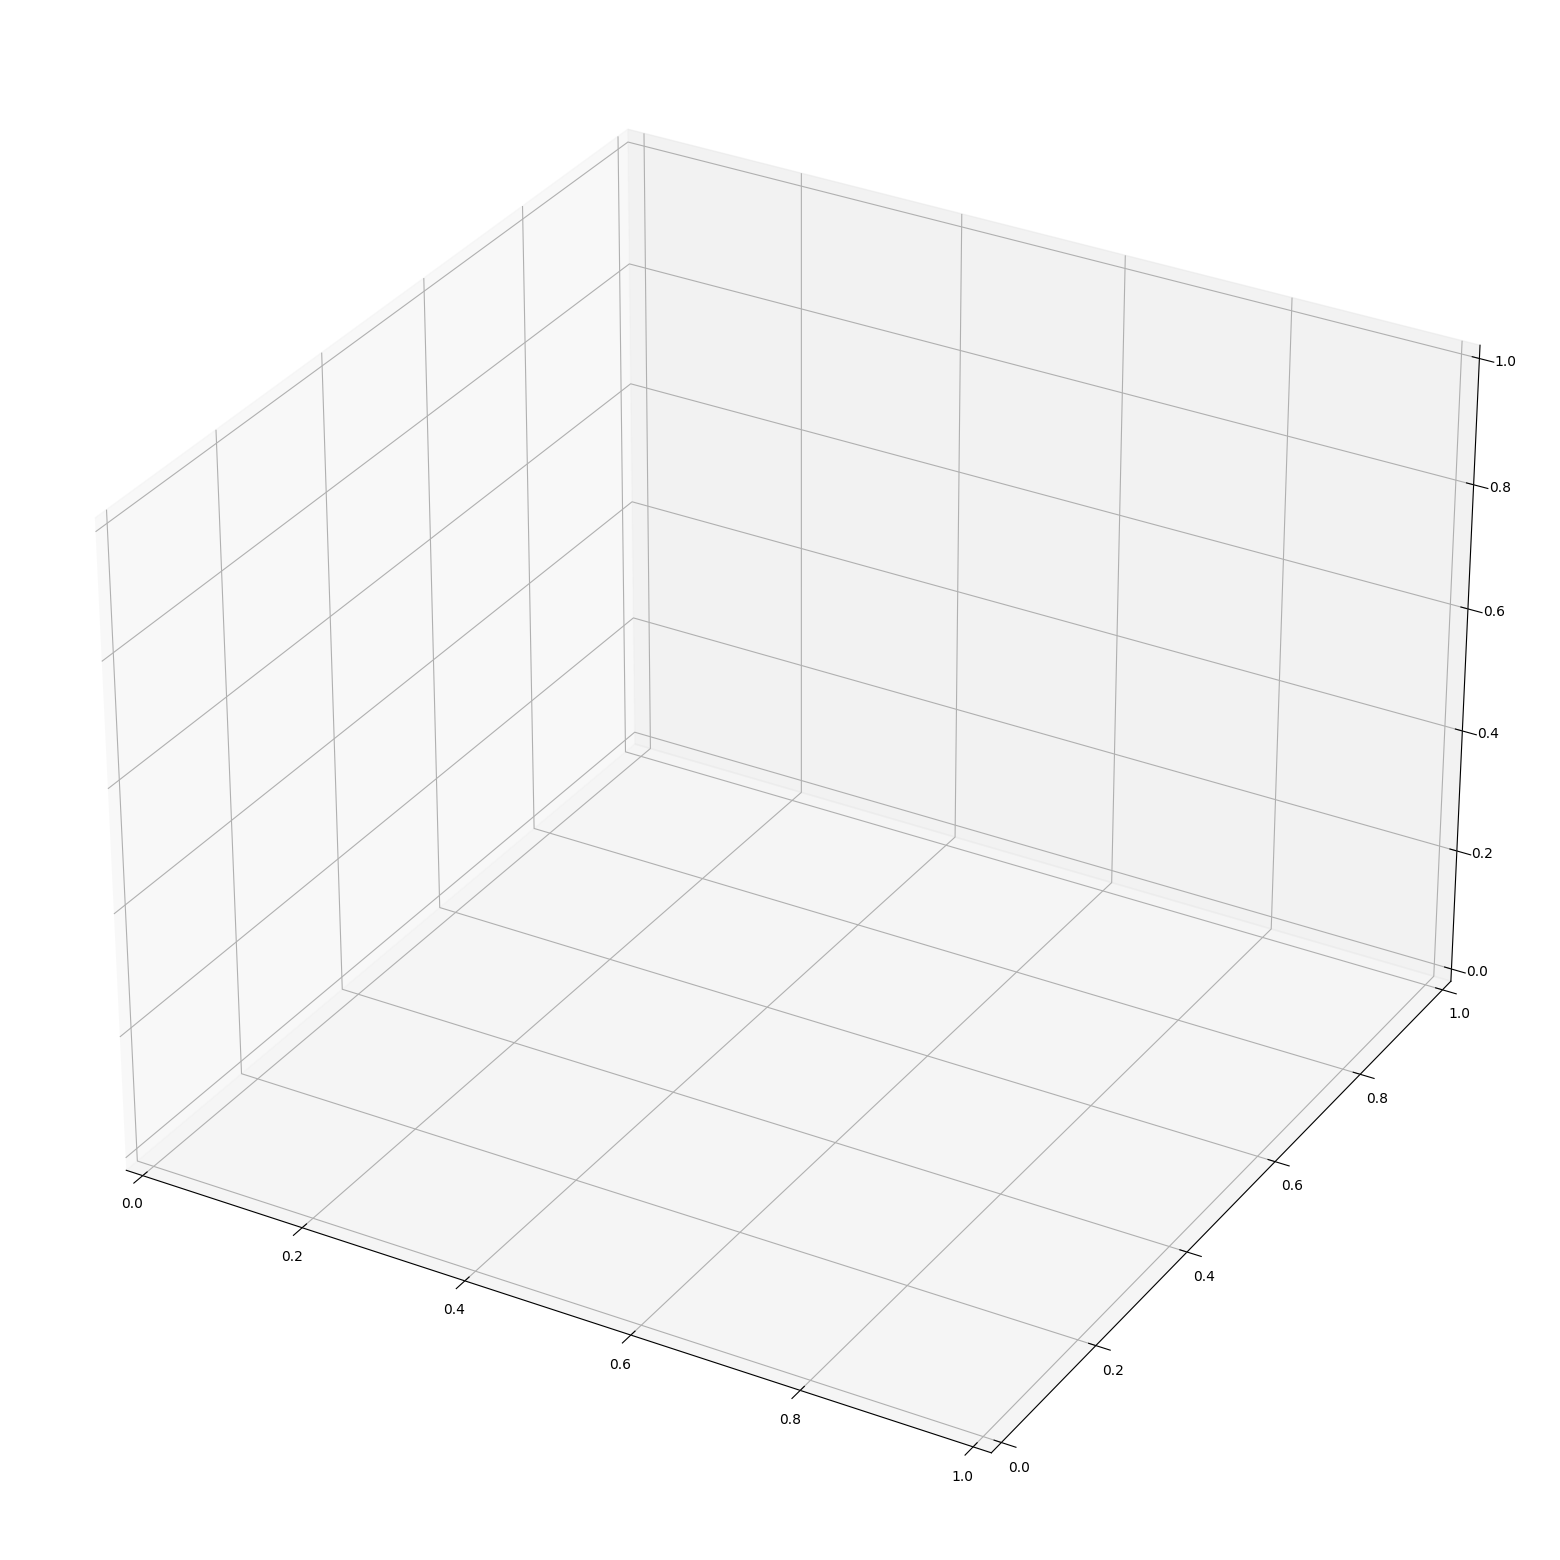

In [8]:
fig = plt.figure(figsize=(20, 20))
ax = fig.add_subplot(111, projection='3d')
for cls in range(21):
    if cls in predictions:
        points_of_class = points_downsampled[predictions == cls]
        ax.scatter(points_of_class[:, 0], points_of_class[:, 1], points_of_class[:, 2], 
                   color=colors[cls], s=20, alpha=0.1, label=class_labels[cls])
leg = ax.legend(fontsize=16)
for lh in leg.legendHandles: 
    lh.set_alpha(1)

In [14]:
import rosbag
import os
import ros_numpy
import numpy as np
from tqdm import tqdm_notebook

In [43]:
pr_data_dir = '/data/topo_graph_from_route1_auto_logs/localization_results'
clouds_dir = '/data/topo_graph_from_route1_auto_logs/clouds'

In [94]:
rt = []
from time import time
for ii, test_name in tqdm_notebook(enumerate(os.listdir(pr_data_dir))):
    test_dir = os.path.join(pr_data_dir, test_name)
    try:
        transforms_ = np.loadtxt(os.path.join(test_dir, 'transforms.txt'))
    except FileNotFoundError:
        continue
    if transforms_.ndim == 1:
        transforms_ = transforms_[np.newaxis, :]
    cand_clouds = {}
    cand_poses = {}
    ref_cloud = np.load(os.path.join(test_dir, 'ref_cloud.npz'))['arr_0']
    ref_cloud = np.array([list(x) for x in ref_cloud if x[2] < 10])
    # Run semantic segmentation
    ref_cloud = np.hstack([ref_cloud, np.zeros((ref_cloud.shape[0], 3))]) # Add black colors
    start = time()
    points_downsampled, colors_downsampled, predictions, probabilities = inference.predict(ref_cloud)
    end = time()
    rt.append(end - start)
    
    # Save segmentation results to the dataset
    np.savez(os.path.join(test_dir, 'points_downsampled.npz'), points_downsampled)
    np.savez(os.path.join(test_dir, 'colors_downsampled.npz'), colors_downsampled)
    np.savez(os.path.join(test_dir, 'predictions.npz'), predictions)
    np.savez(os.path.join(test_dir, 'probabilities.npz'), probabilities)

print(np.mean(rt))

0it [00:00, ?it/s]

  [SalsaNext] projection + normalization: 0.030s
  [SalsaNext] model forward pass:         0.024s
  [SalsaNext] unproject to 3D:            0.013s
  [SalsaNext] colorization:               0.009s
  [SalsaNext] total predict():            0.076s  (160138 points)
  [SalsaNext] projection + normalization: 0.028s
  [SalsaNext] model forward pass:         0.006s
  [SalsaNext] unproject to 3D:            0.012s
  [SalsaNext] colorization:               0.009s
  [SalsaNext] total predict():            0.055s  (164026 points)
  [SalsaNext] projection + normalization: 0.030s
  [SalsaNext] model forward pass:         0.006s
  [SalsaNext] unproject to 3D:            0.012s
  [SalsaNext] colorization:               0.009s
  [SalsaNext] total predict():            0.057s  (161244 points)
  [SalsaNext] projection + normalization: 0.031s
  [SalsaNext] model forward pass:         0.006s
  [SalsaNext] unproject to 3D:            0.012s
  [SalsaNext] colorization:               0.009s
  [SalsaNext] tota

In [46]:
for ii, cloud_name in tqdm_notebook(enumerate(os.listdir(clouds_dir))):
    cloud = np.load(os.path.join(clouds_dir, cloud_name))['arr_0']
    cloud = np.array([list(x) for x in cloud if x[2] < 10])
    # Run semantic segmentation
    cloud = np.hstack([cloud, np.zeros((cloud.shape[0], 3))]) # Add black colors
    points_downsampled, colors_downsampled, predictions, probabilities = inference.predict(cloud)
    # Save segmentation results to the dataset
    test_dir = os.path.join(clouds_dir, 'semantic_{}'.format(cloud_name[:-4]))
    if not os.path.exists(test_dir):
        os.mkdir(test_dir)
    np.savez(os.path.join(test_dir, 'points_downsampled.npz'), points_downsampled)
    np.savez(os.path.join(test_dir, 'colors_downsampled.npz'), colors_downsampled)
    np.savez(os.path.join(test_dir, 'predictions.npz'), predictions)
    np.savez(os.path.join(test_dir, 'probabilities.npz'), probabilities)

0it [00:00, ?it/s]

## Scan matching with semantic

In [83]:
import torch
from time import time
from utils import transform_pcd
from scipy.spatial.transform import Rotation
from local_grid import LocalGrid
from occupancy_grid import Feature2DGlobalRegistrationPipeline
from pointcloud import RansacGlobalRegistrationPipeline
from semantic_grid_ransac import Feature2DGlobalRegistrationPipeline as Feature2DGlobalRegistrationPipelineSemantic

## Estimate precision and recall of scan matching

In [84]:
def get_tf_matrix(transform_for_grid):
        trans_i, trans_j, rot_angle = transform_for_grid
        #print('Trans i trans j rot angle:', trans_i, trans_j, rot_angle)
        plus8 = np.eye(4)
        max_range = 18
        grid_size = 0.1
        plus8[0, 3] = max_range# + 1
        plus8[1, 3] = max_range# + 1
        minus8 = np.eye(4)
        minus8[0, 3] = -max_range# - 1
        minus8[1, 3] = -max_range# - 1
        tf_matrix = np.array([
            [np.cos(rot_angle), np.sin(rot_angle), 0, trans_i * grid_size],
            [-np.sin(rot_angle), np.cos(rot_angle), 0, trans_j * grid_size],
            [0,                  0,                 1, 0],
            [0,                  0,                 0, 1]
        ])
        tf_matrix = minus8 @ tf_matrix @ plus8
        #print('Translation from tf matrix:', tf_matrix[:, 3])
        return tf_matrix

In [85]:
def normalize(angle):
    while angle > np.pi:
        angle -= 2 * np.pi
    while angle < -np.pi:
        angle += 2 * np.pi
    return angle

def transformation_error(gt_pose_shift, tf_matrix_estimated):
    tf_rotation = Rotation.from_matrix(tf_matrix_estimated[:3, :3]).as_rotvec()
    gt_x, gt_y, gt_angle = gt_pose_shift
    #gt_angle = -gt_angle
    estimated_angle = tf_rotation[2]
    estimated_x = tf_matrix_estimated[0, 3]
    estimated_y = tf_matrix_estimated[1, 3]
    return (np.abs(estimated_x - gt_x), np.abs(estimated_y - gt_y), np.abs(normalize(estimated_angle - gt_angle)))

In [86]:
# SemanticKITTI static classes for outdoor matching
# 13=building, 14=fence, 15=vegetation, 16=trunk, 17=terrain, 18=pole, 19=traffic-sign
OUTDOOR_STATIC_CLASSES = [13, 14, 15, 16, 17, 18, 19]
pipeline_semantic = Feature2DGlobalRegistrationPipelineSemantic(outlier_thresholds=[2.5, 1.0, 0.5, 0.25, 0.25],
                                                               ransac_iterations=1000,
                                                               semantic_classes=OUTDOOR_STATIC_CLASSES)
pipeline = Feature2DGlobalRegistrationPipeline(outlier_thresholds=[2.5, 1.0, 0.5, 0.25, 0.25])
pipeline_icp = RansacGlobalRegistrationPipeline(voxel_downsample_size=0.5)

In [87]:
from utils import transform_pcd, get_rel_pose, get_occupancy_grid, apply_pose_shift
from utils import get_iou as get_iou_of_grids

In [88]:
def get_iou(rel_x, rel_y, rel_theta, cur_cloud, v_cloud):
    cur_grid = get_occupancy_grid(cur_cloud)
    v_grid = get_occupancy_grid(v_cloud)
    try:
        return get_iou_of_grids(rel_x, rel_y, rel_theta, cur_grid, v_grid)
    except:
        return np.zeros((360, 360)), 0

In [89]:
pr_data_dir = '/data/topo_graph_from_route1_auto_logs/localization_results'
clouds_dir = '/data/topo_graph_from_route1_auto_logs/clouds'
runtimes = []
runtimes_orb = []
runtimes_icp = []
icp_results = []
semantic_results = []
orb_results = []
ious = []
for ii, test_name in tqdm_notebook(enumerate(os.listdir(pr_data_dir))):
    test_dir = os.path.join(pr_data_dir, test_name)
    try:
        transforms_ = np.loadtxt(os.path.join(test_dir, 'transforms.txt'))
    except FileNotFoundError:
        continue
    if transforms_.ndim == 1:
        transforms_ = transforms_[np.newaxis, :]
    if transforms_.size == 0:
        continue
    cand_clouds = {}
    cand_poses = {}
    cand_probs = {}
    for idx in transforms_[:, 0]:
        cloud = np.load(os.path.join(clouds_dir, "semantic_" + str(int(idx)) + "/points_downsampled.npz"))['arr_0']
        probs = np.load(os.path.join(clouds_dir, f"semantic_{int(idx)}", 'probabilities.npz'))['arr_0']
        cand_clouds[int(idx)] = cloud
        cand_probs[int(idx)] = probs
    ref_cloud = np.load(os.path.join(test_dir, 'points_downsampled.npz'))['arr_0']
    ref_cloud = ref_cloud[:, :3]
    ref_probs = np.load(os.path.join(test_dir, 'probabilities.npz'))['arr_0']
    valid_mask = ~np.isnan(ref_cloud).any(axis=1)
    ref_cloud = ref_cloud[valid_mask]
    ref_probs = ref_probs[valid_mask]
    ref_grid = LocalGrid(resolution=0.2, radius=50, max_range=40, semantic_probability_threshold=0.3, floor_height=0.5, ceil_height=5.0)
    ref_grid.update_from_cloud_and_transform(ref_cloud, ref_probs)
    ref_grid_tensor = torch.Tensor(ref_grid.layers['occupancy'])
    ref_grid_semantic = ref_grid.layers['semantic']
    gt_poses = np.loadtxt(os.path.join(test_dir, 'gt_poses.txt'))
    transforms = {}
    pr_scores = np.loadtxt(os.path.join(test_dir, 'pr_scores.txt'))
    reg_scores = np.loadtxt(os.path.join(test_dir, 'reg_scores.txt'))
    if reg_scores.ndim == 0:
        reg_scores = np.array([reg_scores])
    for i in range(transforms_.size // 7):
        idx = transforms_[i, 0]
        pr_score = pr_scores[i]
        reg_score = reg_scores[i]
        transforms[idx] = transforms_[i, 1:]
        gt_pose = gt_poses[i + 1]
        pose_shift = get_rel_pose(*gt_poses[0], *gt_pose)
        # print('pose shift:', pose_shift)
        dist = np.sqrt(pose_shift[0] ** 2 + pose_shift[1] ** 2)
        cloud = cand_clouds[int(idx)][:, :3]
        probs = cand_probs[int(idx)]
        valid_mask = ~np.isnan(cloud).any(axis=1)
        cloud = cloud[valid_mask]
        probs = probs[valid_mask]
        cand_grid = LocalGrid(resolution=0.2, radius=50, max_range=40, semantic_probability_threshold=0.3, floor_height=0.5, ceil_height=5.0)
        cand_grid.update_from_cloud_and_transform(cloud[:, :3], probs)
        cand_grid_tensor = torch.Tensor(cand_grid.layers['occupancy'])
        cand_grid_semantic = cand_grid.layers['semantic']
        # SEMANTIC METHOD
        start_time = time()
        transform_semantic, score_semantic = pipeline_semantic.infer(ref_grid_tensor, ref_grid_semantic,
                                  cand_grid_tensor, cand_grid_semantic,
                                  verbose=False)
        runtimes.append(time() - start_time)
        grid_aligned, iou = get_iou(*pose_shift, ref_cloud, cloud)
        ious.append(iou)
        print('iou:', iou)
        print('SEMANTIC:', transform_semantic, score_semantic)
        if transform_semantic is not None:
            tf_matrix_semantic = ref_grid.get_tf_matrix_xy(*transform_semantic)#get_tf_matrix(transform_semantic)
            #fitness_sift, ref_wall_mask, ref_floor_mask, cand_wall_mask, cand_floor_mask = fitness_sift_with_masks
            error_semantic = transformation_error(pose_shift, np.linalg.inv(tf_matrix_semantic))
            print('Error semantic:', error_semantic)
        else:
            error_semantic = (np.inf, np.inf, np.inf)
            score_semantic = 0
        semantic_results.append((score_semantic, error_semantic))
        # OLD METHOD
        # start_time = time()
        # transform_orb, score_orb = pipeline.infer(ref_grid_tensor, cand_grid_tensor, verbose=False)
        # # print('OLD:', transform_orb, score_orb)
        # runtimes_orb.append(time() - start_time)
        # if transform_orb is not None:
        #     tf_matrix_orb = ref_grid.get_tf_matrix_xy(*transform_orb)#get_tf_matrix(transform_semantic)
        #     # fitness_sift, ref_wall_mask, ref_floor_mask, cand_wall_mask, cand_floor_mask = fitness_sift_with_masks
        #     error_orb = transformation_error(pose_shift, np.linalg.inv(tf_matrix_orb))
        #     # print('Error orb:', error_orb)
        # else:
        #     error_orb = (np.inf, np.inf, np.inf)
        #     score_orb = 0
        # orb_results.append((score_orb, error_orb))
        # if transform_orb is not None:
        #     tf_matrix = ref_grid.get_tf_matrix_xy(*transform_orb)
        #     x = tf_matrix[0, 3]
        #     y = tf_matrix[1, 3]
        #     _, __, theta = Rotation.from_matrix(tf_matrix[:3, :3]).as_rotvec()
        #     plt.figure(figsize=(20, 20))
        #     ref_cloud_transformed = transform_pcd(ref_cloud, x, y, -theta)
        #     plt.scatter(ref_cloud_transformed[:, 0], ref_cloud_transformed[:, 1], s=5, alpha=0.1)
        #     plt.scatter(cloud[:, 0], cloud[:, 1], s=5, alpha=0.1)
        #     plt.show()

0it [00:00, ?it/s]

iou: 0.0
SEMANTIC: None 0
iou: 0.0
SEMANTIC: None 0
iou: 0.0
SEMANTIC: None 0
iou: 0.0
SEMANTIC: None 0
iou: 0.0
SEMANTIC: None 0
iou: 0.0
SEMANTIC: None 0
iou: 0.0
SEMANTIC: None 0
iou: 0.0
SEMANTIC: None 0
iou: 0.0
SEMANTIC: None 0
iou: 0.0
SEMANTIC: None 0
iou: 0.0
SEMANTIC: None 0
iou: 0.0
SEMANTIC: None 0
iou: 0.0
SEMANTIC: None 0
iou: 0.0
SEMANTIC: None 0
iou: 0.0
SEMANTIC: None 0
iou: 0.0
SEMANTIC: None 0
iou: 0.0
SEMANTIC: None 0
iou: 0.0
SEMANTIC: None 0
iou: 0.0
SEMANTIC: None 0
iou: 0.0
SEMANTIC: None 0
iou: 0.0
SEMANTIC: None 0
iou: 0.0
SEMANTIC: None 0
iou: 0.0
SEMANTIC: None 0
iou: 0.0
SEMANTIC: None 0
iou: 0.0
SEMANTIC: None 0
iou: 0.0
SEMANTIC: None 0
iou: 0.0
SEMANTIC: None 0
iou: 0.0
SEMANTIC: None 0
iou: 0.0
SEMANTIC: None 0
iou: 0.0
SEMANTIC: None 0
iou: 0.0
SEMANTIC: None 0
iou: 0.0
SEMANTIC: None 0
iou: 0.0
SEMANTIC: None 0
iou: 0.0
SEMANTIC: None 0
iou: 0.0
SEMANTIC: None 0
iou: 0.0
SEMANTIC: None 0
iou: 0.0
SEMANTIC: None 0
iou: 0.0
SEMANTIC: None 0
iou: 0.0
SEM

In [85]:
if transform_orb is None:
    x = 0
    y = 0
    theta = 0
else:
    tf_matrix = ref_grid.get_tf_matrix_xy(*transform_orb)
    x = tf_matrix[0, 3]
    y = tf_matrix[1, 3]
    _, __, theta = Rotation.from_matrix(tf_matrix[:3, :3]).as_rotvec()

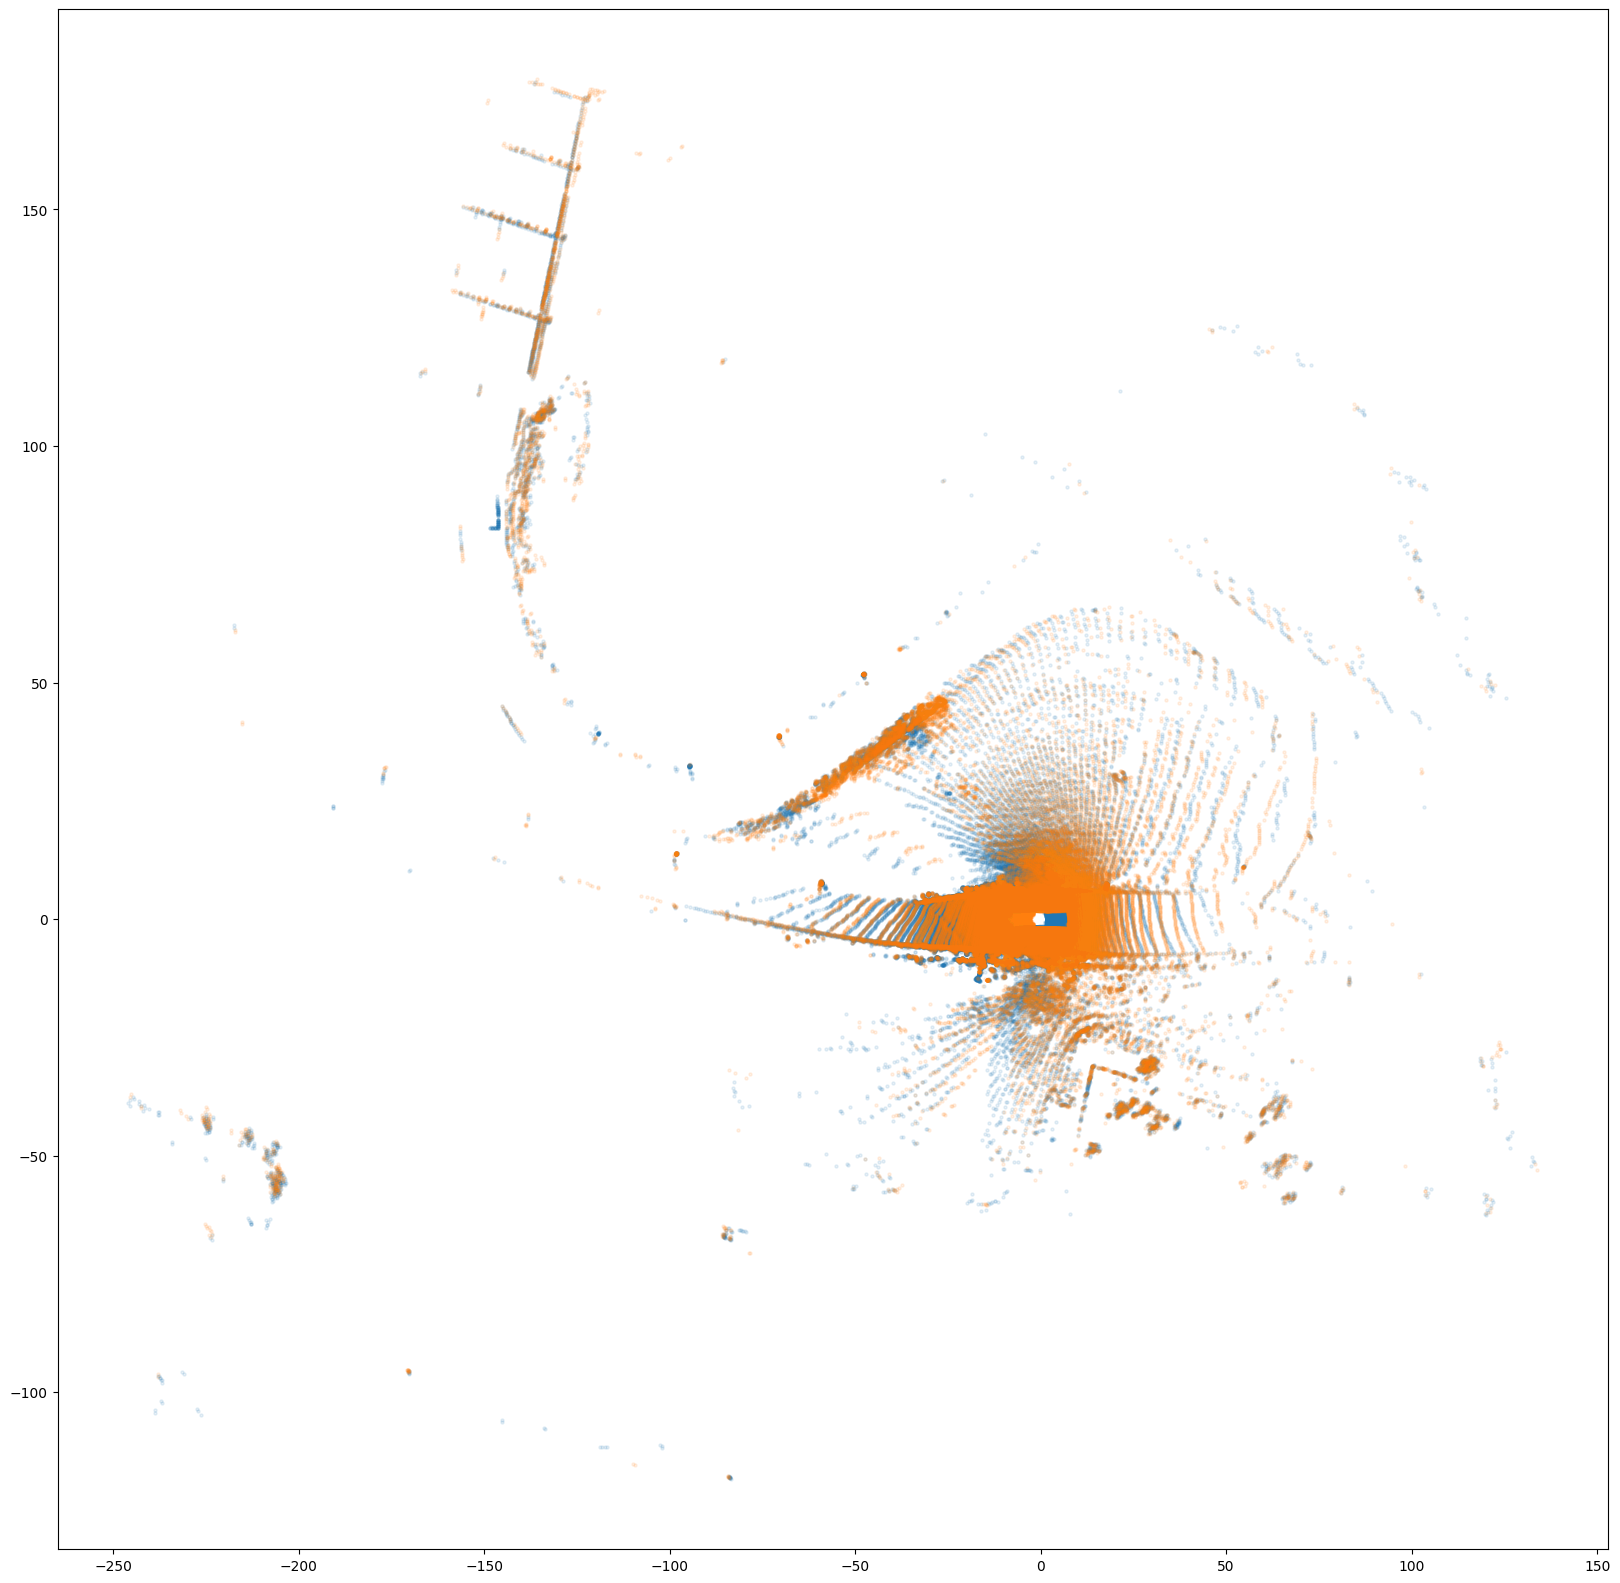

In [92]:
plt.figure(figsize=(20, 20))
ref_cloud_transformed = transform_pcd(ref_cloud, x, y, -theta)
plt.scatter(ref_cloud_transformed[:, 0], ref_cloud_transformed[:, 1], s=5, alpha=0.1)
plt.scatter(cloud[:, 0], cloud[:, 1], s=5, alpha=0.1)

In [90]:
np.mean(runtimes)

0.00970755429457116

### ORB Precision and Recall

In [108]:
threshold = 0.8
n_correct_matches = np.sum([(fitness > threshold) * (max(error) < 0.5) \
                                              for fitness, error in orb_results])
print('Number of correct matches:', n_correct_matches)
n_wrong_matches = np.sum([(fitness > threshold) * (max(error) > 0.5) \
                                              for fitness, error in orb_results])
print('Number of wrong matches:', n_wrong_matches)
n_missed_05 = np.sum([(orb_results[i][0] < threshold) * (ious[i] > 0.5) \
                                                          for i in range(len(ious))])
print('Number of missed matches with IoU > 0.5:', n_missed_05)
n_wrong_05 = np.sum([(orb_results[i][0] > threshold) * (max(orb_results[i][1]) > 0.5) * (ious[i] > 0.5) \
                                                          for i in range(len(ious))])
print('Number of wrong matches with IoU > 0.5:', n_wrong_05)
n_missed_025 = np.sum([(orb_results[i][0] < threshold) * (ious[i] > 0.25) \
                                                          for i in range(len(ious))])
print('Number of missed matches with IoU > 0.25:', n_missed_025)
n_wrong_025 = np.sum([(orb_results[i][0] > threshold) * (max(orb_results[i][1]) > 0.5) * (ious[i] > 0.25) \
                                                          for i in range(len(ious))])
print('Number of wrong matches with IoU > 0.5:', n_wrong_025)

Number of correct matches: 44
Number of wrong matches: 1
Number of missed matches with IoU > 0.5: 6
Number of wrong matches with IoU > 0.5: 0
Number of missed matches with IoU > 0.25: 31
Number of wrong matches with IoU > 0.5: 0


In [109]:
print('Precision:', n_correct_matches / (n_correct_matches + n_wrong_matches))
print('Recall@0.5:', 1 - (n_missed_05 + n_wrong_05) / (np.array(ious) > 0.5).sum())
print('Recall@0.25:', 1 - (n_missed_025 + n_wrong_025) / (np.array(ious) > 0.25).sum())

Precision: 0.9777777777777777
Recall@0.5: 0.8571428571428572
Recall@0.25: 0.5753424657534247


In [27]:
threshold = 0.7
n_correct_matches = np.sum([(fitness > threshold) * (max(error) < 0.5) \
                                              for fitness, error in icp_results])
print('Number of correct matches:', n_correct_matches)
n_wrong_matches = np.sum([(fitness > threshold) * (max(error) > 0.5) \
                                              for fitness, error in icp_results])
print('Number of wrong matches:', n_wrong_matches)
n_missed_05 = np.sum([(icp_results[i][0] < threshold) * (ious[i] > 0.5) \
                                                          for i in range(len(ious))])
print('Number of missed matches with IoU > 0.5:', n_missed_05)
n_wrong_05 = np.sum([(icp_results[i][0] > threshold) * (ious[i] > 0.5) * (max(icp_results[i][1]) > 0.5) \
                                                          for i in range(len(ious))])
print('Number of wrong matches with IoU > 0.5:', n_wrong_05)
n_missed_025 = np.sum([(icp_results[i][0] < threshold) * (ious[i] > 0.25) \
                                                          for i in range(len(ious))])
print('Number of missed matches with IoU > 0.25:', n_missed_025)
n_wrong_025 = np.sum([(icp_results[i][0] > threshold) * (ious[i] > 0.25) * (max(icp_results[i][1]) > 0.5) \
                                                          for i in range(len(ious))])
print('Number of wrong matches with IoU > 0.25:', n_wrong_025)

Number of correct matches: 0.0
Number of wrong matches: 0.0
Number of missed matches with IoU > 0.5: 0.0
Number of wrong matches with IoU > 0.5: 0.0
Number of missed matches with IoU > 0.25: 0.0
Number of wrong matches with IoU > 0.25: 0.0


In [28]:
print('Precision:', n_correct_matches / (n_correct_matches + n_wrong_matches))
print('Recall@0.5:', 1 - (n_missed_05 + n_wrong_05) / (np.array(ious) > 0.5).sum())
print('Recall@0.25:', 1 - (n_missed_025 + n_wrong_025) / (np.array(ious) > 0.25).sum())

Precision: nan
Recall@0.5: nan
Recall@0.25: nan


### Semantic Precision and Recall

In [91]:
threshold = 0.8
n_correct_matches = np.sum([(fitness > threshold) * (max(error) < 0.5) \
                                              for fitness, error in semantic_results])
print('Number of correct matches:', n_correct_matches)
n_wrong_matches = np.sum([(fitness > threshold) * (max(error) > 0.5) \
                                              for fitness, error in semantic_results])
print('Number of wrong matches:', n_wrong_matches)
n_missed_05 = np.sum([(semantic_results[i][0] < threshold) * (ious[i] > 0.5) \
                                                          for i in range(len(ious))])
print('Number of missed matches with IoU > 0.5:', n_missed_05)
n_wrong_05 = np.sum([(semantic_results[i][0] > threshold) * (ious[i] > 0.5) * (max(semantic_results[i][1]) > 0.5) \
                                                          for i in range(len(ious))])
print('Number of wrong matches with IoU > 0.5:', n_wrong_05)
n_missed_025 = np.sum([(semantic_results[i][0] < threshold) * (ious[i] > 0.25) \
                                                          for i in range(len(ious))])
print('Number of missed matches with IoU > 0.25:', n_missed_025)
n_wrong_025 = np.sum([(semantic_results[i][0] > threshold) * (ious[i] > 0.25) * (max(semantic_results[i][1]) > 0.5) \
                                                          for i in range(len(ious))])
print('Number of wrong matches with IoU > 0.25:', n_wrong_025)

Number of correct matches: 45
Number of wrong matches: 1
Number of missed matches with IoU > 0.5: 6
Number of wrong matches with IoU > 0.5: 0
Number of missed matches with IoU > 0.25: 29
Number of wrong matches with IoU > 0.25: 0


In [92]:
print('Precision:', n_correct_matches / (n_correct_matches + n_wrong_matches))
print('Recall@0.5:', 1 - (n_missed_05 + n_wrong_05) / (np.array(ious) > 0.5).sum())
print('Recall@0.25:', 1 - (n_missed_025 + n_wrong_025) / (np.array(ious) > 0.25).sum())

Precision: 0.9782608695652174
Recall@0.5: 0.8571428571428572
Recall@0.25: 0.6027397260273972
